In [1]:
import os
os.getcwd()

from pathlib import Path
from stgae.config.load_config import load_config
from stgae.data.preproccesing import get_columns
import pandas as pd

paths = load_config()['paths']    
data_path = Path(paths['raw_data'])

df = pd.read_csv(data_path / 'data.txt', names=get_columns(), sep=' ')

print(df.head())

         date             time  epoch  moteid  temperature  humidity  light  \
0  2004-03-31  03:38:15.757551      2     1.0     122.1530  -3.91901  11.04   
1  2004-02-28   00:59:16.02785      3     1.0      19.9884  37.09330  45.08   
2  2004-02-28   01:03:16.33393     11     1.0      19.3024  38.46290  45.08   
3  2004-02-28  01:06:16.013453     17     1.0      19.1652  38.80390  45.08   
4  2004-02-28  01:06:46.778088     18     1.0      19.1750  38.83790  45.08   

   voltage  
0  2.03397  
1  2.69964  
2  2.68742  
3  2.68742  
4  2.69964  


In this dataset, an epoch is a discretization of time. The sensors were programmed to wake up, sense, and transmit data periodically (roughly every 31 seconds). However, because these are independent, low-power Mica2Dot motes, there are epochs with more than one observation per sensor. Therefore, I grouped observations by (sensor, epoch) pair. In particular, I kept the first available observation.

In [2]:
# i first sort by datetime, to make sure that then first() means earliest
dt = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str),
                    errors='coerce', infer_datetime_format=True)
df['datetime'] = dt
# drop rows that failed to parse
df = df.dropna(subset=['datetime']).reset_index(drop=True)

df = df.sort_values(by=['datetime'])
df = df.groupby(['epoch', 'moteid'], as_index=False).first()

/var/folders/3g/nq3drgr156qd7b6wgdbymtv80000gn/T/ipykernel_65765/2428091563.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str),


Then, I decided that keeping different timestamps for different sensor inside the same epoch would add only noise and complexity to the model, as I effectively am modelling the problem as one observation per epoch (time series). Therefore, I aggregated datetime per epoch. In particular, for each epoch I calculated the median datetime, and set as datetime that median value.

In [3]:
import numpy as np

df['datetime'] = df.groupby('epoch')['datetime'].transform(
    lambda x: pd.to_datetime(x.astype(np.int64).median())
)

I encoded dates and times using cyclical encoding. I encoded time of the day using a cylical encoding with period 24, and 

In [ ]:
import numpy as np

dt = pd.to_datetime(df['datetime'])

# split into date and time types
df['date'] = dt.dt.date
df['time'] = dt.dt.time

# hours
df['time_hours'] = dt.dt.hour + dt.dt.minute / 60 + dt.dt.second / 3600
df['time_sin'] = np.sin(2 * np.pi * df['time_hours'] / 24)
df['time_cos'] = np.cos(2 * np.pi * df['time_hours'] / 24)

#day of week
df['day_of_week'] = dt.dt.dayofweek
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

#day of month
df['day_of_month'] = dt.dt.day
df['day_month_sin'] = np.sin(2 * np.pi * (df['day_of_month'] - 1) / 31)
df['day_month_cos'] = np.cos(2 * np.pi * (df['day_of_month'] - 1) / 31)

# drop extra columns
df = df.drop(columns=['time_hours', 'date', 'time', 'day_of_week',
                      'day_of_month', 'datetime'])

I dropped all the rows with missing data about the sensor id (few)

Now I count the average number of sensors per epoch. 

In [5]:
# drop rows where moteid is NaN
df = df.dropna(subset=['moteid']).reset_index(drop=True) #526 observations
df.groupby('epoch').size().mean()

np.float64(33.562347412109375)

We have approximately 33.5 measurements per epoch. Given that the original data comes from 54 sensors... I study if there are particular sensors that have very little data.

In [6]:
number_of_epochs = df['epoch'].nunique()
(df.groupby('moteid').size().sort_values() / number_of_epochs).iloc[:20]

moteid
65407.0    0.000015
6485.0     0.000015
33117.0    0.000015
57.0       0.000046
5.0        0.000534
15.0       0.035660
56.0       0.038254
55.0       0.043381
58.0       0.068680
50.0       0.240189
8.0        0.255753
12.0       0.349762
53.0       0.426178
20.0       0.439987
13.0       0.476715
14.0       0.480804
39.0       0.488998
17.0       0.514679
52.0       0.515900
33.0       0.525604
dtype: float64

I observed that there are some possibly mislabled sensors (65407, 6485, 33117, 56, 58, 57, 55) and some sensors with very little data (5, 18, 50, 8, 12). I discarded them entirely.

In [7]:
discard = [65407, 6485, 33117, 56, 58, 57, 5, 18, 50, 8, 12, 55]
df = df[~df['moteid'].isin(discard)]
df['moteid'].unique()

array([11., 19., 21., 47., 52., 13., 14.,  1.,  2.,  3.,  4.,  6., 15.,
       16., 17., 20., 22., 23., 24., 25., 26., 27., 28., 31., 34., 35.,
       38., 40., 42., 43., 45., 46., 48., 49., 54., 32., 51., 29., 33.,
       30., 10., 36.,  7.,  9., 53., 37., 44., 41., 39.])

I observed that feature light is missing in plenty observations.

In [8]:
df.isna().sum() / len(df)

epoch            0.000000
moteid           0.000000
temperature      0.000081
humidity         0.000081
light            0.038438
voltage          0.000000
time_sin         0.000000
time_cos         0.000000
day_sin          0.000000
day_cos          0.000000
day_month_sin    0.000000
day_month_cos    0.000000
dtype: float64

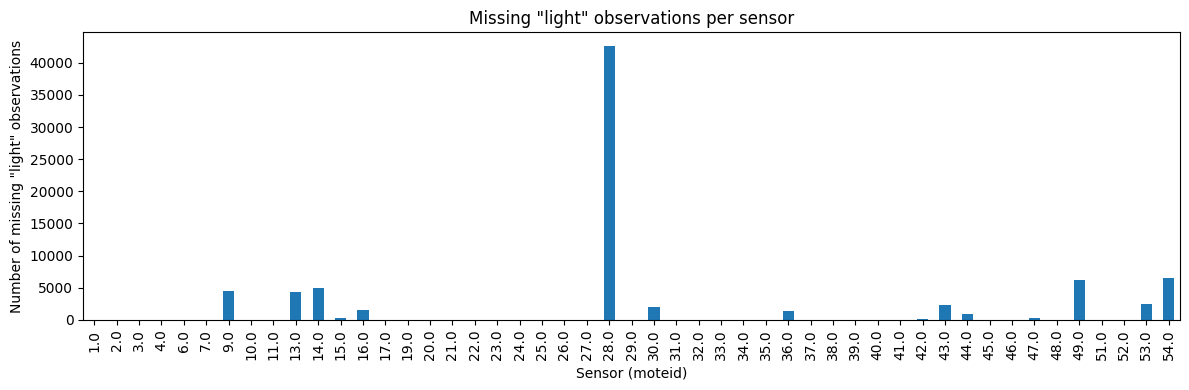

In [9]:
import matplotlib.pyplot as plt

missing_counts = df.groupby('moteid')['light'].apply(lambda x: x.isna().sum()).sort_index()

plt.figure(figsize=(12,4))
missing_counts.plot(kind='bar')
plt.xlabel('Sensor (moteid)')
plt.ylabel('Number of missing "light" observations')
plt.title('Missing "light" observations per sensor')
plt.tight_layout()
plt.show()

Sensor 28 has too many observations where the feature light is missing. I discard it as well.

In [10]:
df = df[df['moteid'] != 28]

df.isna().sum() / len(df)

epoch            0.000000
moteid           0.000000
temperature      0.000083
humidity         0.000082
light            0.018512
voltage          0.000000
time_sin         0.000000
time_cos         0.000000
day_sin          0.000000
day_cos          0.000000
day_month_sin    0.000000
day_month_cos    0.000000
dtype: float64

Remaining missing data is little compared to the size of the dataset. I drop the rows with missing data. Then, I observed that there are epochs with more than one observation per sensors. This happens because epochs is in the end a (given by the dataset) discretization of time. Therefore, in order to treat this as a time series, I aggregated (averaged) observed features per epoch.

In [11]:
df = df.dropna().reset_index(drop=True)

Finally I reindexed epochs and sensors ids.

In [12]:
#rename moteid
moteid_mapping = {old_id: new_id for new_id, old_id in enumerate(sorted(df['moteid'].unique()))}
df['moteid'] = df['moteid'].map(moteid_mapping)

first_epoch = df['epoch'].min()
df['epoch'] = df['epoch'] - first_epoch

assert df['epoch'].max() == df['epoch'].nunique()-1 #all epochs are present
print(len(df['epoch'].unique()))

65536


In [13]:
df.describe()

,epoch,moteid,temperature,humidity,light,voltage,time_sin,time_cos,day_sin,day_cos,day_month_sin,day_month_cos
count,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06
mean,3.287344e+04,2.379872e+01,3.619240e+01,3.479170e+01,4.064233e+02,2.504009e+00,-6.363534e-03,8.593441e-03,-9.072881e-02,5.578679e-02,2.122081e-01,-4.865913e-02
std,1.845445e+04,1.360880e+01,3.443827e+01,1.469368e+01,5.369504e+02,1.664324e-01,7.096220e-01,7.045018e-01,7.204686e-01,6.852602e-01,6.438395e-01,7.335333e-01
min,0.000000e+00,0.000000e+00,-3.840000e+01,-1.854520e+03,3.077160e-15,9.100830e-03,-1.000000e+00,-1.000000e+00,-9.749279e-01,-9.009689e-01,-9.987165e-01,-9.948693e-01
25%,1.733700e+04,1.300000e+01,2.043920e+01,3.279070e+01,3.956000e+01,2.414310e+00,-7.164034e-01,-6.913029e-01,-7.818315e-01,-2.225209e-01,-4.853020e-01,-7.587581e-01
50%,3.295300e+04,2.400000e+01,2.235020e+01,3.948420e+01,1.582400e+02,2.538120e+00,-1.258058e-02,1.359860e-02,0.000000e+00,-2.225209e-01,3.943559e-01,-5.064917e-02
75%,4.788300e+04,3.600000e+01,2.592720e+01,4.348570e+01,5.667200e+02,2.627960e+00,7.073638e-01,7.130465e-01,7.818315e-01,6.234898e-01,7.907757e-01,6.889669e-01
max,6.553500e+04,4.700000e+01,3.855680e+02,1.375120e+02,1.847360e+03,3.159150e+00,1.000000e+00,1.000000e+00,9.749279e-01,1.000000e+00,9.987165e-01,1.000000e+00


I could quickly see that the data contains errors: for example, the maximum temperature is 385 degrees Celsius. To fix this errors that would cause my model to learn from them and thus make it predict garbage, I decided to set a range of physically reasonable values for all features, and drop rows with observed values outside that range. I defined the following intervals:
- Voltage: [2, 3.2]. This comes from the dataset definition.
- Temperature: [8, 38]. Since it is an office environemnt, temperatures outside this range are impossible.
- Humidity: [0, 100]. The only valid theoretical range.
- Light: [0, 2000]. 0 is darkness. 2000 is very bright direct light. The sensors often glitch to extremely high negative or positive integers.

In [14]:
from stgae.data.preproccesing import filter_data_errors

df = filter_data_errors(df)

Dropped 306814 rows (15.2%) due to physical constraints.


In [15]:
# drop rows where moteid is NaN
df.groupby('epoch').size().mean()

np.float64(26.982956784965392)

Let's build the graph.
I decided to use a graph using knn (with k=5), and the edges weighted according to the inverse of the distance. 

Building adjacency matrix

In [17]:
from stgae.data.preproccesing import calculate_distances, calculate_adjacency_matrix

coordinates = pd.read_csv(paths['data_root'] / 'sensor_coordinates.txt', sep=' ')

dist_matrix = calculate_distances(coordinates) #numpy array

k=3 #for k-nearest neighbors adj matrix
exclude_sensors = [28, 5, 18, 50, 8, 12]

A = calculate_adjacency_matrix(dist_matrix, k=k, exclude=exclude_sensors) #assumes renaming of moteid, according to excluded sensors

assert A.shape[0] == len(df['moteid'].unique())

In [18]:
print(A[0,:])

tensor([0.2735, 0.2324, 0.2205, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.2735, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000])


Now, I built the tensors to then create the Dataset.
I created X and M, of shapes
X: shape (T, N, F)
M: shape (T, N, 1)
where
X[t, n] = features of sensor n at epoch t
M[t, n] = 1 if sensor exists at epoch t, else 0

I am only intereseted in predicting original features (temperature, humidity, voltage, light) and not time related features, but I definitely want to use the time data to improve the model reconstruction capability. 

In [19]:
from stgae.data.preproccesing import build_tensors

#shapes:
#X: (time_steps, num_sensors, num_features), M: (time_steps, num_sensors), T_enc: (time_steps, num_time_features)

X, M, T_enc = build_tensors(df, epochs=df['epoch'].unique(), sensors=df['moteid'].unique(), feature_cols=['temperature', 'humidity', 'light', 'voltage'], time_cols=['time_sin', 'time_cos', 'day_sin', 'day_cos', 'day_month_sin', 'day_month_cos'])

Now lets build the dataset.  <br>
For a center time t, and a window size W: <br>
past window: [t-W, ..., t] <br>
future window: [t, ..., t+W] <br>

Masking: masking sensor level per window, that is, for each timestep, choose a subset of known sensors at that the center timestep and mask them in that timestep

In [ ]:
from stgae.data.dataset import STBGNNDataset
from stgae.data.preproccesing import MaskedStandardScaler

train_split = 0.75
val_split = 0.1
T = X.shape[0]
train_size = int(T * train_split)
val_size = int(T * val_split)

#divide into train and val, keeping temporal order, to avoid leakage and learn temporal dependencies
X_train = X[:train_size]
X_val = X[train_size:train_size + val_size]
M_train = M[:train_size]
M_val = M[train_size:train_size + val_size]
T_enc_train = T_enc[:train_size] 
T_enc_val = T_enc[train_size:train_size+val_size]

print(X_train.shape)

#test dataset will be held out only for final evaluation, not for model selection
X_test = X[train_size + val_size:]
M_test = M[train_size + val_size:]
T_enc_test = T_enc[train_size + val_size :]

#i fit the scalar on the training data only, exxcludin the structurally missing data
scaler = MaskedStandardScaler()
scaler.fit(X_train, M_train)

#i scale the tensors remasking missing values back to zero
train_norm = scaler.transform(X_train, M_train, remask_zeros=True)
val_norm = scaler.transform(X_val, M_val, remask_zeros=True)
test_norm = scaler.transform(X_test, M_test, remask_zeros=True)

train_dataset = STBGNNDataset(train_norm, M_train, T_enc, window_size=4, mask_ratio=0.5, split="train")
val_dataset = STBGNNDataset(val_norm, M_val, T_enc_val, window_size=4, mask_ratio=0.5, split="test")
test_dataset = STBGNNDataset(test_norm, M_test, T_enc_test, window_size=4, mask_ratio=0.5, split="test")

print('train dataset length:', len(train_dataset))
print('val dataset length:', len(val_dataset))
print('test dataset length:', len(test_dataset))

(47570, 48, 4)
x_past_masked: torch.Size([5, 48, 4])
x_future_masked: torch.Size([5, 48, 4])
time_past: torch.Size([5, 6])
time_future: torch.Size([5, 6])
target: torch.Size([48, 4])
time_target: torch.Size([6])
loss_mask: torch.Size([48])
train dataset length: 47563
val dataset length: 6335
test dataset length: 9508


Note that masking in the training dataset is stochastic, while masking in the test dataset is deterministic. This is implemented using a local_rng for the test dataset (see code)

Training the model

In [ ]:
# import torch
# from torch.utils.data import DataLoader
# from stgae.model.bistgcn_opt import BiSTGCN
# from stgae.model.train import train_step
# from stgae.config.load_config import load_config
# from stgae.model.evaluate import evaluate
# from stgae.utils.utils import get_device

# # Hyperparameters
# BATCH_SIZE = 32
# EPOCHS = 30
# LEARNING_RATE = 0.002
# HIDDEN_DIM = 32
# DEVICE = get_device()
# SAVE_DIR = load_config()["paths"]["checkpoints"] #dir to store models

# os.makedirs(SAVE_DIR, exist_ok=True)

# # dataloader
# train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) #this does not shuffle timesteps inside samples, but samples inside the batches and improves SGD 
# val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# model = BiSTGCN(target_dim=train_dataset.F, time_dim= train_dataset.F_time, hidden_dim=HIDDEN_DIM, adj=A).to(DEVICE)
# optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# best_loss = float('inf')
# train_losses = []
# val_mses = []

# for epoch in range(EPOCHS):
#     model.train()
#     train_loss = 0.0
    
#     for batch_idx, batch in enumerate(train_dataloader):
#         loss = train_step(batch, model, optimizer, DEVICE)
#         train_loss += loss

#         if batch_idx % 500 == 200:
#             print(f"   Batch {batch_idx+1}/{len(train_dataloader)} - Train Loss: {loss:.6f}")
#     avg_train_loss = train_loss / len(train_dataloader)

#     val_mse, val_mae, val_rmse = evaluate(val_dataloader, model, DEVICE)

#     train_losses.append(avg_train_loss)
#     val_mses.append(val_mse)
    
#     print(f"Epoch [{epoch+1}/{EPOCHS}]")
#     print(f"   Train Loss: {avg_train_loss:.6f}")
#     print(f"   Val MSE:    {val_mse:.6f}")
#     print(f"   Val MAE:    {val_mae:.6f}")
#     print(f"   Val RMSE:   {val_rmse:.6f}")

#     if val_mse < best_loss:
#         best_loss = val_mse
#         best_path = os.path.join(SAVE_DIR, "bistgcn_best.pth")
#         torch.save(model.state_dict(), best_path)
#         print(f"   -> New best model saved with MSE {val_mse} to {best_path}")

#     # save for resuming if crash
#     checkpoint_path = os.path.join(SAVE_DIR, "bistgcn_last.pth")
#     torch.save({
#         'epoch': epoch,
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         'train_loss': avg_train_loss,
#         'loss': val_mse,
#     }, checkpoint_path)

In [24]:
# import matplotlib.pyplot as plt

# epochs = range(1, len(train_losses) + 1)

# plt.figure(figsize=(10, 6))
# plt.plot(epochs, train_losses, label='Train MSE', marker='o')
# plt.plot(epochs, val_mses, label='Validation MSE', marker='o')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Train and Validation Loss over Epochs')
# plt.legend()
# plt.grid(True)
# plt.show()

Evaluating the model.
Now I evaluated the trained model in the test dataset.

In [25]:
import torch
from torch.utils.data import DataLoader
from stgae.model.bistgcn_opt import BiSTGCN
from stgae.model.train import train_step
from stgae.config.load_config import load_config
from stgae.model.evaluate import evaluate
from stgae.utils.utils import get_device

import torch
#load model
BATCH_SIZE = 32
CHECKPOINTS = load_config()["paths"]["checkpoints"]
HIDDEN_DIM = 32
DEVICE = get_device()


model_path = os.path.join(CHECKPOINTS, "bistgcn_best.pth")
model = BiSTGCN(target_dim=train_dataset.F, time_dim= train_dataset.F_time, hidden_dim=HIDDEN_DIM, adj=A).to(DEVICE)
checkpoint = torch.load(model_path, map_location=DEVICE)
model.load_state_dict(checkpoint)
model.eval()

test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

eval_mse, eval_mae, eval_rmse = evaluate(test_dataloader, model, DEVICE)

print(f'MSE = {eval_mse} | MAE =  {eval_mae} | RMSE = {eval_rmse}')

MSE = 0.19660490750016382 | MAE =  0.3113377255281346 | RMSE = 0.4315621155820437


Then, to analyze the model, I visualized the reconstruction. I defined a function to visualize the reconstruction for a chosen sensor in the evaluation dataset, in the masked data points.

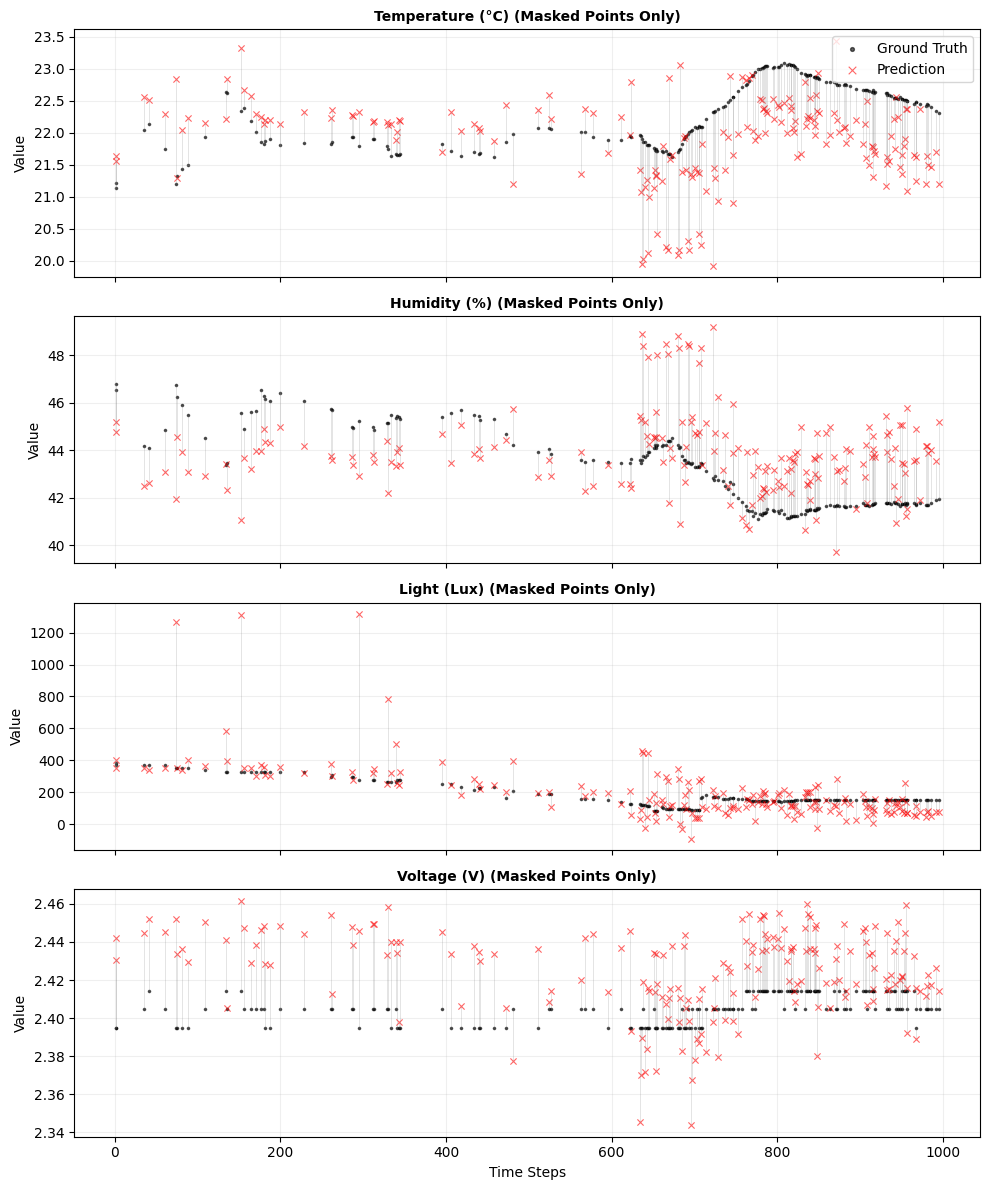

In [ ]:
from stgae.model.visualize import visualize_sensor_reconstruction

#labels
feature_labels = ["Temperature (°C)", "Humidity (%)", "Light (Lux)", "Voltage (V)"]

sensor_to_plot = 35

# test_loader uast be shuffle=False so the plot is  continuous 
visualize_sensor_reconstruction(
    dataloader=test_dataloader,  
    model=model, 
    scaler=scaler, 
    sensor_idx=sensor_to_plot, 
    feature_names=feature_labels, 
    device=DEVICE,
    num_steps=1000 
)

**Comparison against Forward Fill** <br>
To be able to understand the result of my model, I compared it against a baseline forward fill.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

#i calculate the 
cutoff_value = df['epoch'].max() - 9508
df_train = df[df['epoch'] <= cutoff_value].copy()
df_test = df[df['epoch'] > cutoff_value].copy()

# 2. Standardize (Train stats applied to Test)
sensor_cols = ['temperature', 'humidity', 'light', 'voltage']
train_means = df_train[sensor_cols].mean()
train_stds = df_train[sensor_cols].std()

# Apply standardization
df_test[sensor_cols] = (df_test[sensor_cols] - train_means) / train_stds

# Sort is CRITICAL for ffill
df_test = df_test.sort_values(by=['moteid', 'epoch'])

# --- NEW MASKING LOGIC ---

# 3. Create the "Structured" Mask
# We want to drop 50% of sensors PER EPOCH.
# We do this by sampling indices.
np.random.seed(42)

# This finds the indices of the rows we want to "hide"
# "groupby('epoch')" treats each time step as a bucket
# "sample(frac=0.5)" picks 50% of the sensors in that bucket
masked_indices = df_test.groupby('epoch').sample(frac=0.5, random_state=42).index

# Create corrupted dataframe
df_corrupted = df_test.copy()

# Set ALL sensor columns to NaN for the selected rows
# This simulates total packet loss for those specific sensors at those specific times
df_corrupted.loc[masked_indices, sensor_cols] = np.nan

# --- IMPUTATION & EVALUATION ---

# 4. Apply Forward Fill Imputation (Per Sensor)
# If a value is NaN, it looks at the previous timestamp for THAT SAME sensor.
df_imputed = df_corrupted.copy()
df_imputed[sensor_cols] = df_imputed.groupby('moteid')[sensor_cols].ffill()

# 5. Calculate MSE
# We only compare the rows that were in our 'masked_indices' list
# (The ones we artificially destroyed)

# Extract ground truth for the masked rows
y_true = df_test.loc[masked_indices, sensor_cols]

# Extract predicted values for the masked rows
y_pred = df_imputed.loc[masked_indices, sensor_cols]

# 6. Final Score
# Note: ffill might fail for the very first epoch of a sensor (nothing to carry forward).
# Those will remain NaN. We must exclude them from the MSE calculation.
# We stack to flatten the data so we can remove NaNs easily
y_true_flat = y_true.stack()
y_pred_flat = y_pred.stack()

# Align indices (stack might drop NaNs differently) and find valid pairs
# We only want pairs where we have both a Truth and a Prediction
common_index = y_true_flat.index.intersection(y_pred_flat.index)

mse = mean_squared_error(y_true_flat.loc[common_index], y_pred_flat.loc[common_index])

print(f"Standardized Forward Fill MSE (50% Sensors masked per Epoch): {mse:.4f}")

Standardized Forward Fill MSE (50% Sensors masked per Epoch): 0.0024
